In [ ]:
# Imports
import matplotlib.pyplot as plt
import numpy as np
from TorchRL_MAC_utils import default_cfg, train, evaluate, evaluate_with_comparison

## 1. Configure Training

Using small settings for quick demonstration. For better results, increase `num_iters` to 500-1000.

In [ ]:
# Create configuration
cfg = default_cfg()

# --- CRITICAL FOR PPO STABILITY ---
# PPO needs more data per update. 
# 128 steps * 4 envs = 512 total samples per update (Minimum for stable PPO)
cfg.rollout_len = 128        
cfg.num_envs = 4

# PPO Hyperparameters 
cfg.ppo_epochs = 4           
cfg.clip_param = 0.2         
cfg.entropy_coef = 0.01      

# Training run
cfg.num_iters = 2000         
cfg.lr = 3e-4
cfg.hidden_dim = 128         
cfg.log_interval = 10        

# Evaluation settings
cfg.eval_episodes = 20       
cfg.eval_interval = 200     

print("Configuration:")
print(f"  Training iterations: {cfg.num_iters}")
print(f"  Batch size (steps * envs): {cfg.rollout_len * cfg.num_envs}")
print(f"  Learning rate: {cfg.lr}")


Configuration:
  Training iterations: 5000
  Rollout length: 128
  Parallel environments: 4
  Learning rate: 0.0003
  Evaluation episodes: 20
Configuration:
  Training iterations: 15000
  Batch size (steps * envs): 512
  Learning rate: 0.0003


## 2. Train Policy

Train separate actor networks for each agent with a centralized critic.

In [22]:
# Train
print("Starting training...\n")
checkpoint_path, stats = train(cfg)

print(f"\n✓ Training complete!")
print(f"  Checkpoint: {checkpoint_path}")
print(f"  Final loss: {stats['losses'][-1]:.3f}")
print(f"  Final return: {stats['returns'][-1]:.3f}")
print(f"  Final entropy: {stats['entropies'][-1]:.3f}")

Starting training...

Starting training with config:
MacConfig(env_name='simple_reference', num_envs=4, max_cycles=25, continuous_actions=False, hidden_dim=128, actor_layers=2, critic_layers=2, num_iters=15000, rollout_len=128, lr=0.0003, gamma=0.99, entropy_coef=0.01, value_coef=0.5, max_grad_norm=0.5, eval_episodes=20, success_threshold=5.0, seed=42, device='cpu', checkpoint_dir='./checkpoints', log_interval=10)
Iter 10/15000 | Loss: 589.097 | Return: -29.752 | Entropy: 7.820
Iter 20/15000 | Loss: 606.996 | Return: -29.478 | Entropy: 7.821
Iter 30/15000 | Loss: 608.964 | Return: -30.257 | Entropy: 7.822
Iter 40/15000 | Loss: 523.567 | Return: -28.401 | Entropy: 7.822
Iter 50/15000 | Loss: 585.942 | Return: -30.493 | Entropy: 7.822
Iter 60/15000 | Loss: 514.883 | Return: -28.478 | Entropy: 7.822
Iter 70/15000 | Loss: 446.837 | Return: -27.183 | Entropy: 7.822
Iter 80/15000 | Loss: 578.603 | Return: -31.440 | Entropy: 7.822
Iter 90/15000 | Loss: 570.132 | Return: -30.949 | Entropy: 7.8

## 3. Plot Training Progress

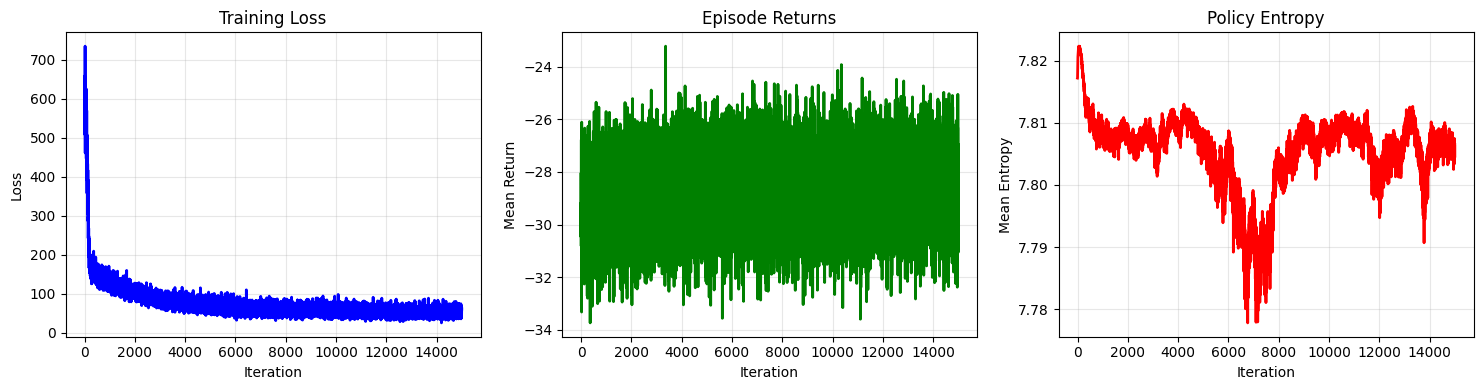

Training curves saved to: mac_training_curves.png


In [23]:
# Plot training curves
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Loss
axes[0].plot(stats['losses'], 'b-', linewidth=2)
axes[0].set_xlabel('Iteration')
axes[0].set_ylabel('Loss')
axes[0].set_title('Training Loss')
axes[0].grid(True, alpha=0.3)

# Returns
axes[1].plot(stats['returns'], 'g-', linewidth=2)
axes[1].set_xlabel('Iteration')
axes[1].set_ylabel('Mean Return')
axes[1].set_title('Episode Returns')
axes[1].grid(True, alpha=0.3)

# Entropy
axes[2].plot(stats['entropies'], 'r-', linewidth=2)
axes[2].set_xlabel('Iteration')
axes[2].set_ylabel('Mean Entropy')
axes[2].set_title('Policy Entropy')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('mac_training_curves.png', dpi=100, bbox_inches='tight')
plt.show()

print("Training curves saved to: mac_training_curves.png")

## 4. Evaluate: Normal Mode (With Communication)

In [24]:
# Evaluate with communication
print("Evaluating with communication...\n")
metrics_normal = evaluate(cfg, checkpoint_path, mode="normal")

print("\nNormal Mode Results:")
print(f"  Success Rate: {metrics_normal['success_rate']:.3f}")
print(f"  Communication Cost: {metrics_normal['comm_cost']:.4f}")

Evaluating with communication...


Evaluating in mode: normal
  Success Rate: 0.000
  Comm Cost: 0.9840

Normal Mode Results:
  Success Rate: 0.000
  Communication Cost: 0.9840


## 5. Evaluate: No-Communication Mode (Speaker Silenced)

In [ ]:
# Evaluate without communication
print("Evaluating without communication (speaker silenced)...\n")
metrics_no_comm = evaluate(cfg, checkpoint_path, mode="no_comm")

print("\nNo-Communication Mode Results:")
print(f"  Success Rate: {metrics_no_comm['success_rate']:.3f}")
print(f"  Communication Cost: {metrics_no_comm['comm_cost']:.4f} (should be ~0)")

Evaluating without communication (speaker silenced)...


Evaluating in mode: no_comm
  Success Rate: 0.000
  Comm Cost: 0.0000

No-Communication Mode Results:
  Success Rate: 0.000
  Communication Cost: 0.0000 (should be ~0)


: 

## 6. Compare and Compute Communication Efficiency

In [18]:
# Run full comparison
print("Running full comparison...\n")
metrics = evaluate_with_comparison(cfg, checkpoint_path)

print("\n" + "="*50)
print("FINAL METRICS")
print("="*50)
print(f"Success Rate (with comm):    {metrics['success_rate']:.3f}")
print(f"Success Rate (no comm):      {metrics['success_rate_no_comm']:.3f}")
print(f"Communication Cost:          {metrics['comm_cost']:.4f}")
print(f"Communication Gain:          {metrics['comm_gain']:.3f}")
print(f"Communication Efficiency:    {metrics['comm_efficiency']:.3f}")
print("="*50)

Running full comparison...


Evaluating in mode: normal
  Success Rate: 0.000
  Comm Cost: 0.9860

Evaluating in mode: no_comm
  Success Rate: 0.000
  Comm Cost: 0.0000

=== Final Metrics ===
Success Rate (normal): 0.000
Success Rate (no_comm): 0.000
Comm Cost: 0.9860
Comm Gain: 0.000
Comm Efficiency: 0.000

FINAL METRICS
Success Rate (with comm):    0.000
Success Rate (no comm):      0.000
Communication Cost:          0.9860
Communication Gain:          0.000
Communication Efficiency:    0.000


## 7. Visualize Comparison

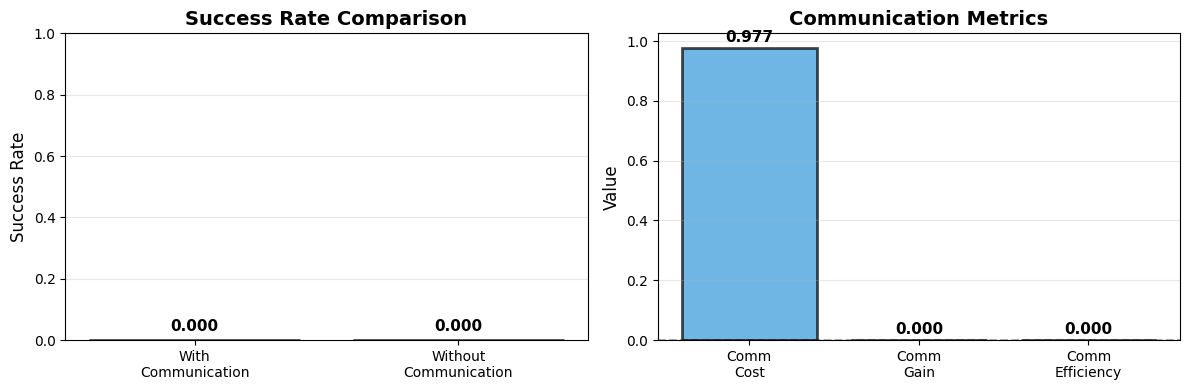


Evaluation results saved to: mac_evaluation_results.png


In [9]:
# Create comparison plot
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Success rate comparison
modes = ['With\nCommunication', 'Without\nCommunication']
success_rates = [metrics['success_rate'], metrics['success_rate_no_comm']]
colors = ['#2ecc71', '#e74c3c']

bars = axes[0].bar(modes, success_rates, color=colors, alpha=0.7, edgecolor='black', linewidth=2)
axes[0].set_ylabel('Success Rate', fontsize=12)
axes[0].set_title('Success Rate Comparison', fontsize=14, fontweight='bold')
axes[0].set_ylim([0, 1])
axes[0].grid(True, alpha=0.3, axis='y')

# Add value labels on bars
for bar, val in zip(bars, success_rates):
    height = bar.get_height()
    axes[0].text(bar.get_x() + bar.get_width()/2., height + 0.02,
                f'{val:.3f}', ha='center', va='bottom', fontsize=11, fontweight='bold')

# Communication metrics
metric_names = ['Comm\nCost', 'Comm\nGain', 'Comm\nEfficiency']
metric_values = [metrics['comm_cost'], metrics['comm_gain'], metrics['comm_efficiency']]
metric_colors = ['#3498db', '#9b59b6', '#f39c12']

bars = axes[1].bar(metric_names, metric_values, color=metric_colors, alpha=0.7, edgecolor='black', linewidth=2)
axes[1].set_ylabel('Value', fontsize=12)
axes[1].set_title('Communication Metrics', fontsize=14, fontweight='bold')
axes[1].axhline(y=0, color='k', linestyle='--', alpha=0.3)
axes[1].grid(True, alpha=0.3, axis='y')

# Add value labels
for bar, val in zip(bars, metric_values):
    height = bar.get_height()
    y_pos = height + 0.01 if height >= 0 else height - 0.01
    va = 'bottom' if height >= 0 else 'top'
    axes[1].text(bar.get_x() + bar.get_width()/2., y_pos,
                f'{val:.3f}', ha='center', va=va, fontsize=11, fontweight='bold')

plt.tight_layout()
plt.savefig('mac_evaluation_results.png', dpi=100, bbox_inches='tight')
plt.show()

print("\nEvaluation results saved to: mac_evaluation_results.png")

## 8. Interpretation

### Metrics Explanation:

- **Success Rate (with comm)**: How often the listener reaches the correct landmark when the speaker can communicate
- **Success Rate (no comm)**: How often the listener succeeds without any speaker signals (baseline)
- **Communication Cost**: Average "expense" of speaker actions (0 = no communication, higher = more communication)
- **Communication Gain**: Improvement from communication (= success_with_comm - success_no_comm)
- **Communication Efficiency**: How much success per unit of communication (= gain / cost)

### Good results show:
1. Higher success rate with communication than without
2. Positive communication gain
3. High communication efficiency (agents learned to use minimal but informative signals)

### Notes:
- With only 10 training iterations, the policy is undertrained
- For meaningful results, train for 500-1000 iterations
- Increase `eval_episodes` to 100+ for stable metrics

In [ ]:
# Summary table
print("\nMetrics Summary:")
print("-" * 60)
print(f"{'Metric':<30} {'Value':<15} {'Interpretation'}")
print("-" * 60)
print(f"{'Success (with comm)':<30} {metrics['success_rate']:<15.3f} {'Higher is better'}")
print(f"{'Success (no comm)':<30} {metrics['success_rate_no_comm']:<15.3f} {'Baseline performance'}")
print(f"{'Communication Cost':<30} {metrics['comm_cost']:<15.4f} {'Lower is better'}")
print(f"{'Communication Gain':<30} {metrics['comm_gain']:<15.3f} {'Higher is better'}")
print(f"{'Communication Efficiency':<30} {metrics['comm_efficiency']:<15.3f} {'Higher is better'}")
print("-" * 60)

# Interpretation
if metrics['comm_gain'] > 0.1:
    print(" Communication is helpful! Agents learned to coordinate.")
elif metrics['comm_gain'] > 0:
    print("~ Communication slightly helps, but could be improved with more training.")
else:
    print("XX Communication not yet helpful. Needs more training or hyperparameter tuning.")

if metrics['comm_efficiency'] > 1.0:
    print(" High communication efficiency! Agents use communication effectively.")
elif metrics['comm_efficiency'] > 0:
    print("~ Moderate efficiency. Room for improvement.")
else:
    print("XX Low efficiency. Communication is costly relative to benefit.")


Metrics Summary:
------------------------------------------------------------
Metric                         Value           Interpretation
------------------------------------------------------------
Success (with comm)            0.000           Higher is better
Success (no comm)              0.000           Baseline performance
Communication Cost             0.9860          Lower is better
Communication Gain             0.000           Higher is better
Communication Efficiency       0.000           Higher is better
------------------------------------------------------------
✗ Communication not yet helpful. Needs more training or hyperparameter tuning.
✗ Low efficiency. Communication is costly relative to benefit.


## Next Steps

To improve results:
1. Increase `cfg.num_iters` to 500-1000
2. Tune hyperparameters (`lr`, `gamma`, `entropy_coef`)
3. Increase `cfg.eval_episodes` to 100 for stable metrics
4. Try different network architectures (`hidden_dim`, `actor_layers`)
5. Experiment with reward shaping or curriculum learning